# GOLDEN 04_self_reinforcement

**Thesis section:** `sec:results:sr`  
**Provenance:** Self-Reinforcement. Ported verbatim from scripts/build_nb_032.py (superseded).  
**Data:** results/mas/final_dataset_new_system  
**Figures exported to:** thesis/plots/sr/ (fig1_psr_violin .. fig6_subgroups)  
**Status:** reproducible from committed data.

This is a GOLDEN notebook: it recomputes every number in the named thesis section from raw data and exports every figure to the fixed `thesis/plots/` path the LaTeX already includes. Numbers are printed in labelled blocks for manual copy into the thesis. See `notebooks/golden/INDEX.md` for the full section->notebook map.


# 032 — Self-Reinforcement Analysis (new_system dataset, R=50)

Full SR analysis on `results/mas/final_dataset_new_system` (both GPQA and HiddenBench,
35 tasks × 6 configs × 50 reps = 21,000 reps, new anti-conformity system prompt).

Figures exported to `thesis/plots/sr/` for LaTeX inclusion.


In [1]:
import sys
sys.path.insert(0, '../..')

import json
from pathlib import Path
from collections import Counter as _Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from src.metrics.self_reinforcement import extract_runs, summarise_runs, count_all_runs

BASE       = Path('../..') / 'results' / 'mas' / 'final_dataset_new_system'
EXPORT     = Path('../..') / 'thesis' / 'plots' / 'sr'
EXPORT.mkdir(parents=True, exist_ok=True)

W_VALUES   = [1, 2, 5]
TOPOS      = ['fc', 'star']
DATASETS   = ['gpqa', 'hiddenbench']
from src.viz.thesis_style import (apply_style, W_COLORS, DS_COLORS, T_COLORS,
                                   DS_LABELS, T_LABELS, CMAP_SEQ, FIGSIZES, no_grid)
apply_style()
print('setup ok')

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


setup ok


In [2]:
def load_all():
    run_rows  = []
    rep_rows  = []
    task_rows = []

    for f in sorted(BASE.glob('**/*.json')):
        d    = json.loads(f.read_text())
        W    = d['W']
        ds   = d['dataset']
        topo = d.get('topology_name', 'fc')
        qid  = d['question_id']
        gt   = d['ground_truth']
        reps = d['repetitions']
        runs = extract_runs(reps)

        for row in runs:
            run_rows.append({'W': W, 'dataset': ds, 'topology': topo,
                             'qid': qid, 'ground_truth': gt, **row})

        for rep_idx, rep in enumerate(reps):
            T_r = len(rep['trajectory']) - 1
            init_votes = [rep['trajectory'][0]['phase_b'][i]['vote']
                          for i in range(rep['N'])]
            init_correct_frac = sum(v == gt for v in init_votes) / rep['N']
            rep_runs = [r for r in runs if r['rep_idx'] == rep_idx]
            slopes   = [r['slope'] for r in rep_runs]
            p_sr     = float(np.mean(np.array(slopes) > 0)) if slopes else np.nan
            mean_sl  = float(np.mean(slopes)) if slopes else np.nan
            rep_rows.append({
                'W': W, 'dataset': ds, 'topology': topo, 'qid': qid,
                'rep_idx': rep_idx, 'correct': rep['correct'],
                'n_rounds': T_r,
                'init_correct_frac': init_correct_frac,
                'n_runs': len(rep_runs),
                'p_sr': p_sr, 'mean_slope': mean_sl,
            })

        summ = summarise_runs(runs)
        task_rows.append({
            'W': W, 'dataset': ds, 'topology': topo, 'qid': qid,
            'accuracy': float(np.mean([r['correct'] for r in reps])),
            'mean_rounds': float(np.mean([len(r['trajectory']) - 1 for r in reps])),
            **summ,
        })

    return (
        pd.DataFrame(run_rows),
        pd.DataFrame(rep_rows),
        pd.DataFrame(task_rows),
    )

runs_df, reps_df, tasks_df = load_all()
print(f'Run records : {len(runs_df):,}')
print(f'Rep records : {len(reps_df):,}')
print(f'Task records: {len(tasks_df):,}')
print()
print(tasks_df.groupby(['dataset','topology','W'])['n_runs'].sum().to_string())

Run records : 94,173
Rep records : 21,000
Task records: 420

dataset      topology  W
gpqa         fc        1    7435
                       2    7263
                       5    7330
             star      1    7722
                       2    7538
                       5    7620
hiddenbench  fc        1    8102
                       2    7787
                       5    7805
             star      1    9015
                       2    8288
                       5    8268


In [3]:
# Descriptive accounting
total_counts        = {'n_total': 0, 'n_short': 0, 'n_kept': 0}
n_single_run_agents = 0
total_agent_trajs   = 0

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    reps = d['repetitions']
    c    = count_all_runs(reps)
    for k in total_counts:
        total_counts[k] += c[k]
    for rep in reps:
        traj = rep['trajectory']
        T_r  = len(traj) - 1
        N    = len(traj[0]['phase_b'])
        for ag in range(N):
            total_agent_trajs += 1
            votes = [traj[t]['phase_b'][ag]['vote'] for t in range(T_r + 1)]
            if len(set(votes)) == 1:
                n_single_run_agents += 1

n_total     = total_counts['n_total']
n_extracted = len(runs_df)
n_ceiling   = int(runs_df['ceiling_hit'].sum())
n_flat      = int((runs_df['slope'] == 0).sum())

print('─' * 58)
print('RUN FILTER ACCOUNTING')
print('─' * 58)
print(f'All stable runs (no length filter)  : {n_total:>7,}')
print(f'  dropped  length < 3               : {total_counts["n_short"]:>7,}  ({100*total_counts["n_short"]/n_total:.1f}%)')
print(f'  kept (length ≥ 3) = run records   : {n_extracted:>7,}  ({100*n_extracted/n_total:.1f}%)')
print(f'    of which flat β = 0             : {n_flat:>7,}  ({100*n_flat/n_extracted:.1f}%)')
print()
print(f'Ceiling hits (end_conf=10)          : {n_ceiling:>7,}  ({100*n_ceiling/n_extracted:.1f}% of run records)')
print()
print(f'Agent trajectories total            : {total_agent_trajs:>7,}')
print(f'Never flipped (single vote)         : {n_single_run_agents:>7,}  ({100*n_single_run_agents/total_agent_trajs:.1f}%)')
print(f'Flipped at least once               : {total_agent_trajs-n_single_run_agents:>7,}  ({100*(total_agent_trajs-n_single_run_agents)/total_agent_trajs:.1f}%)')

──────────────────────────────────────────────────────────
RUN FILTER ACCOUNTING
──────────────────────────────────────────────────────────
All stable runs (no length filter)  : 169,060
  dropped  length < 3               :  74,887  (44.3%)
  kept (length ≥ 3) = run records   :  94,173  (55.7%)
    of which flat β = 0             :  16,221  (17.2%)

Ceiling hits (end_conf=10)          :  12,549  (13.3% of run records)

Agent trajectories total            :  84,000
Never flipped (single vote)         :  36,531  (43.5%)
Flipped at least once               :  47,469  (56.5%)


---
## Part 1 — Prevalence: Is SR present?

In [4]:
# p_SR per cell
grp = (tasks_df.groupby(['dataset','topology','W'])['p_sr']
       .agg(['mean','sem']).round(4).reset_index())
print('p_SR mean and SEM per cell:')
print(grp.to_string(index=False))
print()

# Sign test per cell
print('=== Binomial sign test: p_SR > 0.5 per (dataset, topology, W) ===')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            sub = (tasks_df[(tasks_df['dataset']==ds) &
                            (tasks_df['topology']==topo) &
                            (tasks_df['W']==w)]['p_sr'].dropna())
            n_above = int((sub > 0.5).sum())
            res = sp_stats.binomtest(n_above, len(sub), p=0.5, alternative='greater')
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  '
                  f'p_sr={sub.mean():.3f}  above={n_above}/{len(sub)}  p={res.pvalue:.4f}')

p_SR mean and SEM per cell:
    dataset topology  W   mean    sem
       gpqa       fc  1 0.8254 0.0114
       gpqa       fc  2 0.8145 0.0166
       gpqa       fc  5 0.7686 0.0166
       gpqa     star  1 0.8129 0.0114
       gpqa     star  2 0.7748 0.0165
       gpqa     star  5 0.7424 0.0163
hiddenbench       fc  1 0.8512 0.0094
hiddenbench       fc  2 0.8751 0.0096
hiddenbench       fc  5 0.8250 0.0114
hiddenbench     star  1 0.8350 0.0083
hiddenbench     star  2 0.8174 0.0104
hiddenbench     star  5 0.7905 0.0114

=== Binomial sign test: p_SR > 0.5 per (dataset, topology, W) ===
  GPQA         fc    W=1  p_sr=0.825  above=35/35  p=0.0000
  GPQA         fc    W=2  p_sr=0.815  above=35/35  p=0.0000
  GPQA         fc    W=5  p_sr=0.769  above=35/35  p=0.0000
  GPQA         star  W=1  p_sr=0.813  above=35/35  p=0.0000
  GPQA         star  W=2  p_sr=0.775  above=35/35  p=0.0000
  GPQA         star  W=5  p_sr=0.742  above=35/35  p=0.0000
  HiddenBench  fc    W=1  p_sr=0.851  above=35/35  

In [5]:
# Cluster bootstrap 95% CI
N_BOOT = 2000

def cluster_bootstrap(sub_runs, n_boot=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    by_repcell = {k: g['slope'].values for k, g in sub_runs.groupby(['qid', 'rep_idx'])}
    task_reps = {}
    for (q, r) in by_repcell:
        task_reps.setdefault(q, []).append((q, r))
    tasks = list(task_reps)
    p_boot, m_boot = np.empty(n_boot), np.empty(n_boot)
    for b in range(n_boot):
        acc = []
        for q in tasks:
            reps = task_reps[q]
            for idx in rng.integers(0, len(reps), len(reps)):
                acc.append(by_repcell[reps[idx]])
        s = np.concatenate(acc)
        p_boot[b] = (s > 0).mean()
        m_boot[b] = s.mean()
    return np.percentile(p_boot, [2.5, 97.5]), np.percentile(m_boot, [2.5, 97.5])

print(f'=== Cluster bootstrap 95% CI (n_boot={N_BOOT}) ===')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            sr = runs_df[(runs_df['dataset']==ds) & (runs_df['topology']==topo) &
                         (runs_df['W']==w)][['qid', 'rep_idx', 'slope']].dropna()
            (plo, phi), (mlo, mhi) = cluster_bootstrap(sr)
            p_point = (sr['slope'] > 0).mean()
            m_point = sr['slope'].mean()
            flag_p = 'p_SR>0.5' if plo > 0.5 else 'ns'
            flag_m = 'slope>0'  if mlo > 0   else 'ns'
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  '
                  f'p_SR={p_point:.3f} [{plo:.3f}, {phi:.3f}] {flag_p:9s} '
                  f'slope={m_point:.3f} [{mlo:.3f}, {mhi:.3f}] {flag_m}')

=== Cluster bootstrap 95% CI (n_boot=2000) ===


  GPQA         fc    W=1  p_SR=0.824 [0.814, 0.833] p_SR>0.5  slope=0.516 [0.506, 0.527] slope>0


  GPQA         fc    W=2  p_SR=0.813 [0.803, 0.823] p_SR>0.5  slope=0.496 [0.485, 0.507] slope>0


  GPQA         fc    W=5  p_SR=0.766 [0.756, 0.776] p_SR>0.5  slope=0.446 [0.434, 0.457] slope>0


  GPQA         star  W=1  p_SR=0.810 [0.802, 0.819] p_SR>0.5  slope=0.469 [0.458, 0.480] slope>0


...

  HiddenBench  fc    W=2  p_SR=0.873 [0.864, 0.881] p_SR>0.5  slope=0.456 [0.447, 0.466] slope>0


  HiddenBench  fc    W=5  p_SR=0.822 [0.813, 0.832] p_SR>0.5  slope=0.395 [0.386, 0.405] slope>0


  HiddenBench  star  W=1  p_SR=0.833 [0.824, 0.841] p_SR>0.5  slope=0.355 [0.346, 0.364] slope>0


  HiddenBench  star  W=2  p_SR=0.815 [0.805, 0.824] p_SR>0.5  slope=0.353 [0.343, 0.361] slope>0


  HiddenBench  star  W=5  p_SR=0.788 [0.778, 0.798] p_SR>0.5  slope=0.334 [0.325, 0.343] slope>0


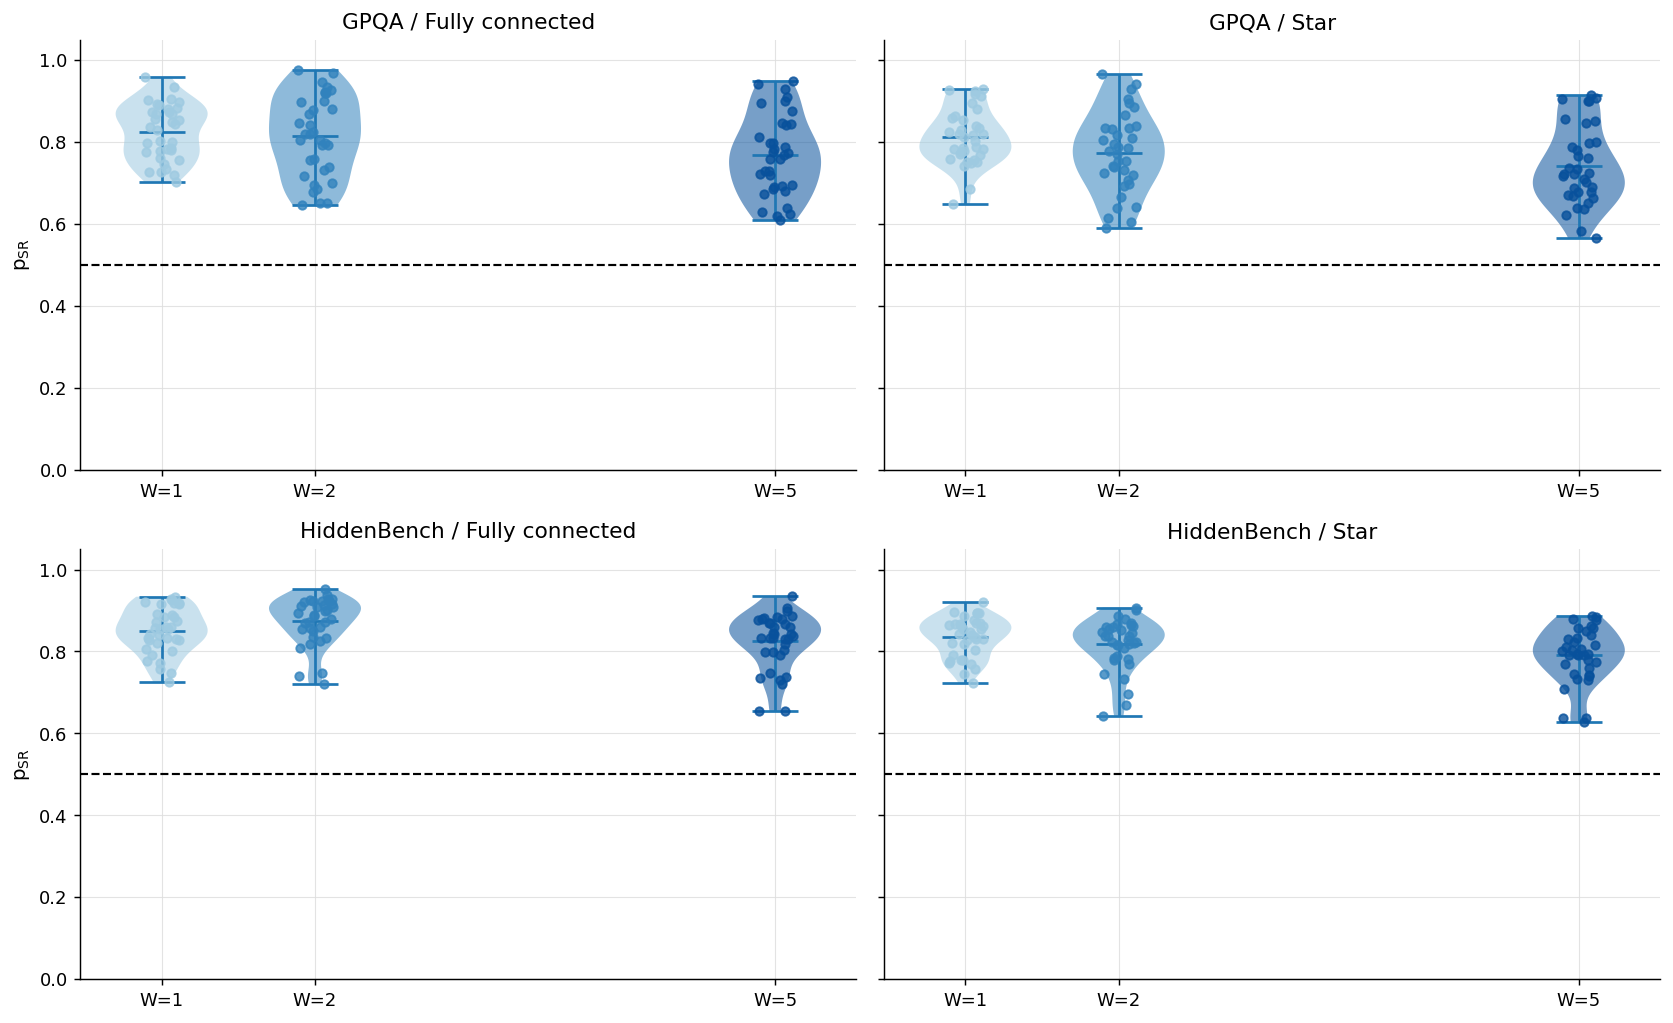

fig1 saved


In [6]:
# Fig 1 — p_SR violin
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        parts = ax.violinplot(
            [sub[sub['W']==w]['p_sr'].dropna().values for w in W_VALUES],
            positions=W_VALUES, widths=0.6,
            showmeans=True, showmedians=False,
        )
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(list(W_COLORS.values())[i])
            pc.set_alpha(0.55)
        for w in W_VALUES:
            vals   = sub[sub['W']==w]['p_sr'].dropna().values
            jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(vals))
            ax.scatter(w + jitter, vals, s=22, color=W_COLORS[w], alpha=0.8, zorder=3)
        ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2)
        ax.set_xticks(W_VALUES)
        ax.set_xticklabels([f'W={w}' for w in W_VALUES])
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.set_ylim(0, 1.05)
        if col == 0:
            ax.set_ylabel('$p_{SR}$')

plt.tight_layout()
fig.savefig(EXPORT / 'fig1_psr_violin.png')
plt.show()
print('fig1 saved')

---
## Part 2 — Strength Scaling (W) and Configuration Effects

In [7]:
# Mean slope table
ms = (tasks_df.groupby(['dataset','topology','W'])[['p_sr','mean_slope']]
      .mean().round(4))
print('Mean p_SR and slope per cell:')
print(ms.to_string())
print()

# Page trend test
print('=== Page trend test: mean_slope ordered W1 < W2 < W5 ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        mat = sub.pivot(index='qid', columns='W', values='mean_slope')[W_VALUES].dropna()
        means = mat.mean().values
        up   = sp_stats.page_trend_test(mat.values)
        down = sp_stats.page_trend_test(mat.values[:, ::-1])
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  '
              f'W1/W2/W5={means[0]:.3f}/{means[1]:.3f}/{means[2]:.3f}  '
              f'p_up={up.pvalue:.2e}  p_down={down.pvalue:.2e}  (n={len(mat)})')

print()
print('=== Topology comparison: fc vs star (MWU two-sided) ===')
for ds in DATASETS:
    for w in W_VALUES:
        fc   = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']=='fc')   & (tasks_df['W']==w)]['mean_slope'].dropna()
        star = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']=='star') & (tasks_df['W']==w)]['mean_slope'].dropna()
        stat, p = sp_stats.mannwhitneyu(fc, star, alternative='two-sided')
        print(f'  {DS_LABELS[ds]:12s} W={w}  fc={fc.mean():.3f}  star={star.mean():.3f}  p={p:.4f}')

print()
print('=== Dataset comparison: GPQA vs HiddenBench (MWU two-sided) ===')
for topo in TOPOS:
    for w in W_VALUES:
        g = tasks_df[(tasks_df['dataset']=='gpqa')        & (tasks_df['topology']==topo) & (tasks_df['W']==w)]['mean_slope'].dropna()
        h = tasks_df[(tasks_df['dataset']=='hiddenbench') & (tasks_df['topology']==topo) & (tasks_df['W']==w)]['mean_slope'].dropna()
        stat, p = sp_stats.mannwhitneyu(g, h, alternative='two-sided')
        print(f'  {topo:5s} W={w}  GPQA={g.mean():.3f}  HiddenBench={h.mean():.3f}  p={p:.4f}')

Mean p_SR and slope per cell:
                          p_sr  mean_slope
dataset     topology W                    
gpqa        fc       1  0.8254      0.5190
                     2  0.8145      0.4978
                     5  0.7686      0.4488
            star     1  0.8129      0.4735
                     2  0.7748      0.4323
                     5  0.7424      0.4014
hiddenbench fc       1  0.8512      0.4444
                     2  0.8751      0.4592
                     5  0.8250      0.3981
            star     1  0.8350      0.3580
                     2  0.8174      0.3555
                     5  0.7905      0.3368

=== Page trend test: mean_slope ordered W1 < W2 < W5 ===
  GPQA         fc     W1/W2/W5=0.519/0.498/0.449  p_up=1.00e+00  p_down=1.57e-06  (n=35)
  GPQA         star   W1/W2/W5=0.474/0.432/0.401  p_up=1.00e+00  p_down=3.75e-08  (n=35)
  HiddenBench  fc     W1/W2/W5=0.444/0.459/0.398  p_up=1.00e+00  p_down=2.64e-04  (n=35)
  HiddenBench  star   W1/W2/W5=0.358/0.356/

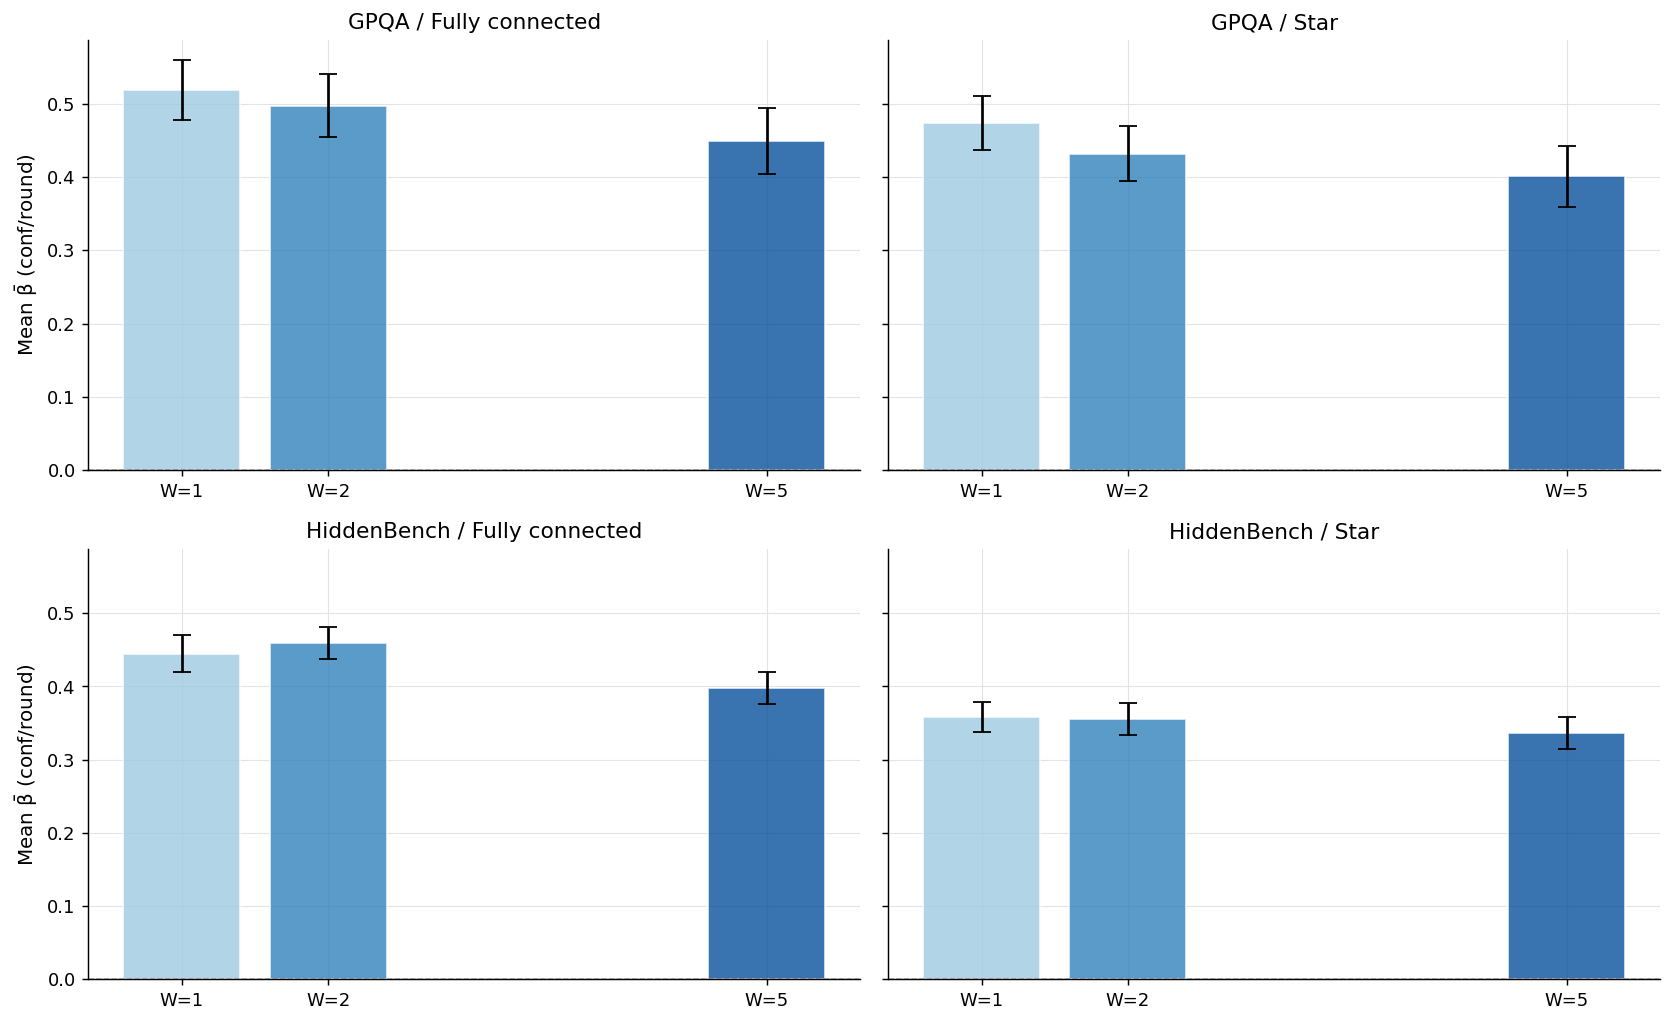

fig2 saved


In [8]:
# Fig 2 — mean slope by W
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax   = axes[row][col]
        sub  = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        means = [sub[sub['W']==w]['mean_slope'].mean() for w in W_VALUES]
        sems  = [sub[sub['W']==w]['mean_slope'].sem()  for w in W_VALUES]
        ax.bar(W_VALUES, means, yerr=[1.96*s for s in sems],
               color=[W_COLORS[w] for w in W_VALUES],
               capsize=5, alpha=0.8, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(W_VALUES)
        ax.set_xticklabels([f'W={w}' for w in W_VALUES])
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        if col == 0:
            ax.set_ylabel(r'Mean $\bar{\beta}$ (conf/round)')

plt.tight_layout()
fig.savefig(EXPORT / 'fig2_mean_slope_W.png')
plt.show()
print('fig2 saved')

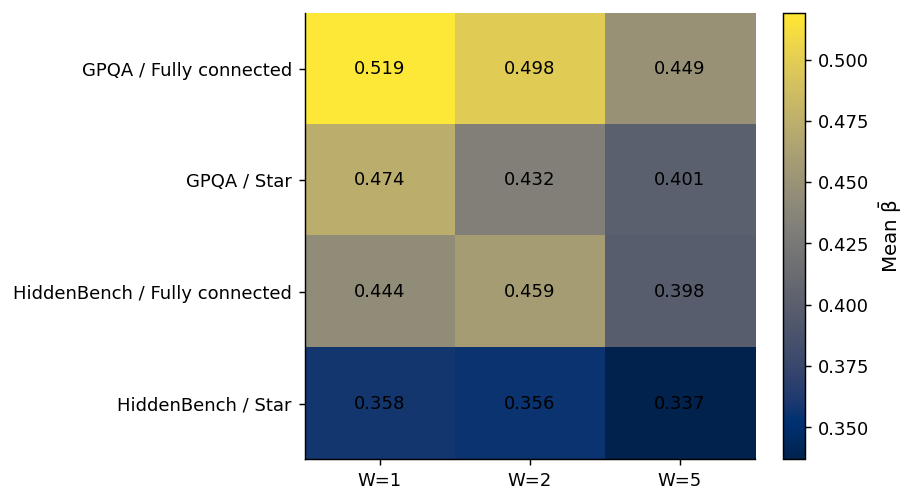

fig3 saved


In [9]:
# Fig 3 — heatmap
pivot = (tasks_df.groupby(['dataset','topology','W'])['mean_slope']
         .mean().unstack('W').round(3))
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap=CMAP_SEQ)
no_grid(ax)
ax.set_xticks(range(len(W_VALUES)))
ax.set_xticklabels([f'W={w}' for w in W_VALUES])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{DS_LABELS.get(ds,ds)} / {T_LABELS.get(t,t)}'
                    for ds, t in pivot.index])
for i in range(len(pivot.index)):
    for j in range(len(W_VALUES)):
        ax.text(j, i, f'{pivot.values[i,j]:.3f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label=r'Mean $\bar{\beta}$')
plt.tight_layout()
fig.savefig(EXPORT / 'fig3_heatmap.png')
plt.show()
print('fig3 saved')

---
## Part 3 — Subgroup Analysis

In [10]:
# Annotate runs_df with rep-level context
never_flip_set = set()
init_dist_map  = {}

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W, ds, topo, qid = d['W'], d['dataset'], d.get('topology_name','fc'), d['question_id']
    for rep_idx, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']
        T_r  = len(traj) - 1
        N    = len(traj[0]['phase_b'])
        agent_votes = [[traj[t]['phase_b'][i]['vote'] for t in range(T_r+1)]
                       for i in range(N)]
        flipped = any(len(set(av)) > 1 for av in agent_votes)
        if not flipped:
            never_flip_set.add((ds, topo, W, qid, rep_idx))
        init_votes = [traj[0]['phase_b'][i]['vote'] for i in range(N)]
        cnts = sorted(_Counter(init_votes).values(), reverse=True)
        while len(cnts) < 4: cnts.append(0)
        init_dist_map[(ds, topo, W, qid, rep_idx)] = '-'.join(str(c) for c in cnts)

runs_df['never_flip'] = runs_df.apply(
    lambda r: (r['dataset'], r['topology'], r['W'], r['qid'], r['rep_idx']) in never_flip_set,
    axis=1
)
runs_df['init_dist'] = runs_df.apply(
    lambda r: init_dist_map.get((r['dataset'], r['topology'], r['W'], r['qid'], r['rep_idx']), None),
    axis=1
)
init_correct_map = reps_df.set_index(
    ['dataset','topology','W','qid','rep_idx'])['init_correct_frac'].to_dict()
runs_df['init_correct_frac'] = runs_df.apply(
    lambda r: init_correct_map.get((r['dataset'],r['topology'],r['W'],r['qid'],r['rep_idx'])), axis=1
)
runs_df['init_majority_correct'] = runs_df['init_correct_frac'] > 0.5

def _group_stats(mask):
    s = runs_df[mask]['slope'].dropna()
    p_sr = float((s > 0).mean())
    return p_sr, float(s.mean()), len(s)

splits = {
    'Ceiling hit':         runs_df['ceiling_hit'] == True,
    'No ceiling':          runs_df['ceiling_hit'] == False,
    'Terminal':            runs_df['terminal'] == True,
    'Non-terminal':        runs_df['terminal'] == False,
    'Init majority correct': runs_df['init_majority_correct'] == True,
    'Init majority wrong':   runs_df['init_majority_correct'] == False,
    'Never flip (rep)':    runs_df['never_flip'] == True,
    'Flip at some point':  runs_df['never_flip'] == False,
}

rows = []
for label, mask in splits.items():
    p_sr, ms, n = _group_stats(mask)
    rows.append({'Group': label, 'n_runs': n, 'p_SR': round(p_sr,3), 'mean_slope': round(ms,3)})
print(pd.DataFrame(rows).to_string(index=False))

DIST_ORDER = ['4-0-0-0', '3-1-0-0', '2-2-0-0', '2-1-1-0', '1-1-1-1']
print()
print('=== Init distribution stats ===')
for d in DIST_ORDER:
    grp = runs_df[runs_df['init_dist']==d]['slope'].dropna()
    p_sr = (grp > 0).mean()
    print(f'  {d}  n={len(grp):,}  p_SR={p_sr:.3f}  mean_slope={grp.mean():.3f}')

valid_dist = [runs_df[runs_df['init_dist']==d]['slope'].dropna().values for d in DIST_ORDER if len(runs_df[runs_df['init_dist']==d]) > 1]
stat_kw, p_kw = sp_stats.kruskal(*valid_dist)
print(f'Kruskal-Wallis across init_dist: H={stat_kw:.1f}  p={p_kw:.4e}')

print()
print('=== MWU tests for binary splits ===')
BINARY_PAIRS = [
    ('ceiling_hit',           False,  True,   'No ceiling',    'Ceiling hit'),
    ('terminal',              False,  True,   'Non-terminal',  'Terminal'),
    ('init_majority_correct', False,  True,   'Init wrong',    'Init correct'),
    ('never_flip',            False,  True,   'Flipped',       'Never flipped'),
]
for col, val_lo, val_hi, lbl_lo, lbl_hi in BINARY_PAIRS:
    lo = runs_df[runs_df[col] == val_lo]['slope'].dropna()
    hi = runs_df[runs_df[col] == val_hi]['slope'].dropna()
    stat, p = sp_stats.mannwhitneyu(hi, lo, alternative='two-sided')
    print(f'  {lbl_lo:20s} mu={lo.mean():.3f}  vs  {lbl_hi:20s} mu={hi.mean():.3f}  p={p:.4f}')

                Group  n_runs  p_SR  mean_slope
          Ceiling hit   12549 0.910       0.565
           No ceiling   81624 0.794       0.399
             Terminal   83529 0.826       0.442
         Non-terminal   10644 0.676       0.261
Init majority correct   11862 0.842       0.536
  Init majority wrong   82311 0.805       0.405
     Never flip (rep)   12748 0.910       0.698
   Flip at some point   81425 0.793       0.378

=== Init distribution stats ===
  4-0-0-0  n=13,844  p_SR=0.897  mean_slope=0.669
  3-1-0-0  n=35,302  p_SR=0.819  mean_slope=0.409
  2-2-0-0  n=20,431  p_SR=0.793  mean_slope=0.368
  2-1-1-0  n=23,717  p_SR=0.763  mean_slope=0.344
  1-1-1-1  n=879  p_SR=0.652  mean_slope=0.290
Kruskal-Wallis across init_dist: H=7914.1  p=0.0000e+00

=== MWU tests for binary splits ===
  No ceiling           mu=0.399  vs  Ceiling hit          mu=0.565  p=0.0000
  Non-terminal         mu=0.261  vs  Terminal             mu=0.442  p=0.0000
  Init wrong           mu=0.405  vs  Init

/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_80573/1200010032.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


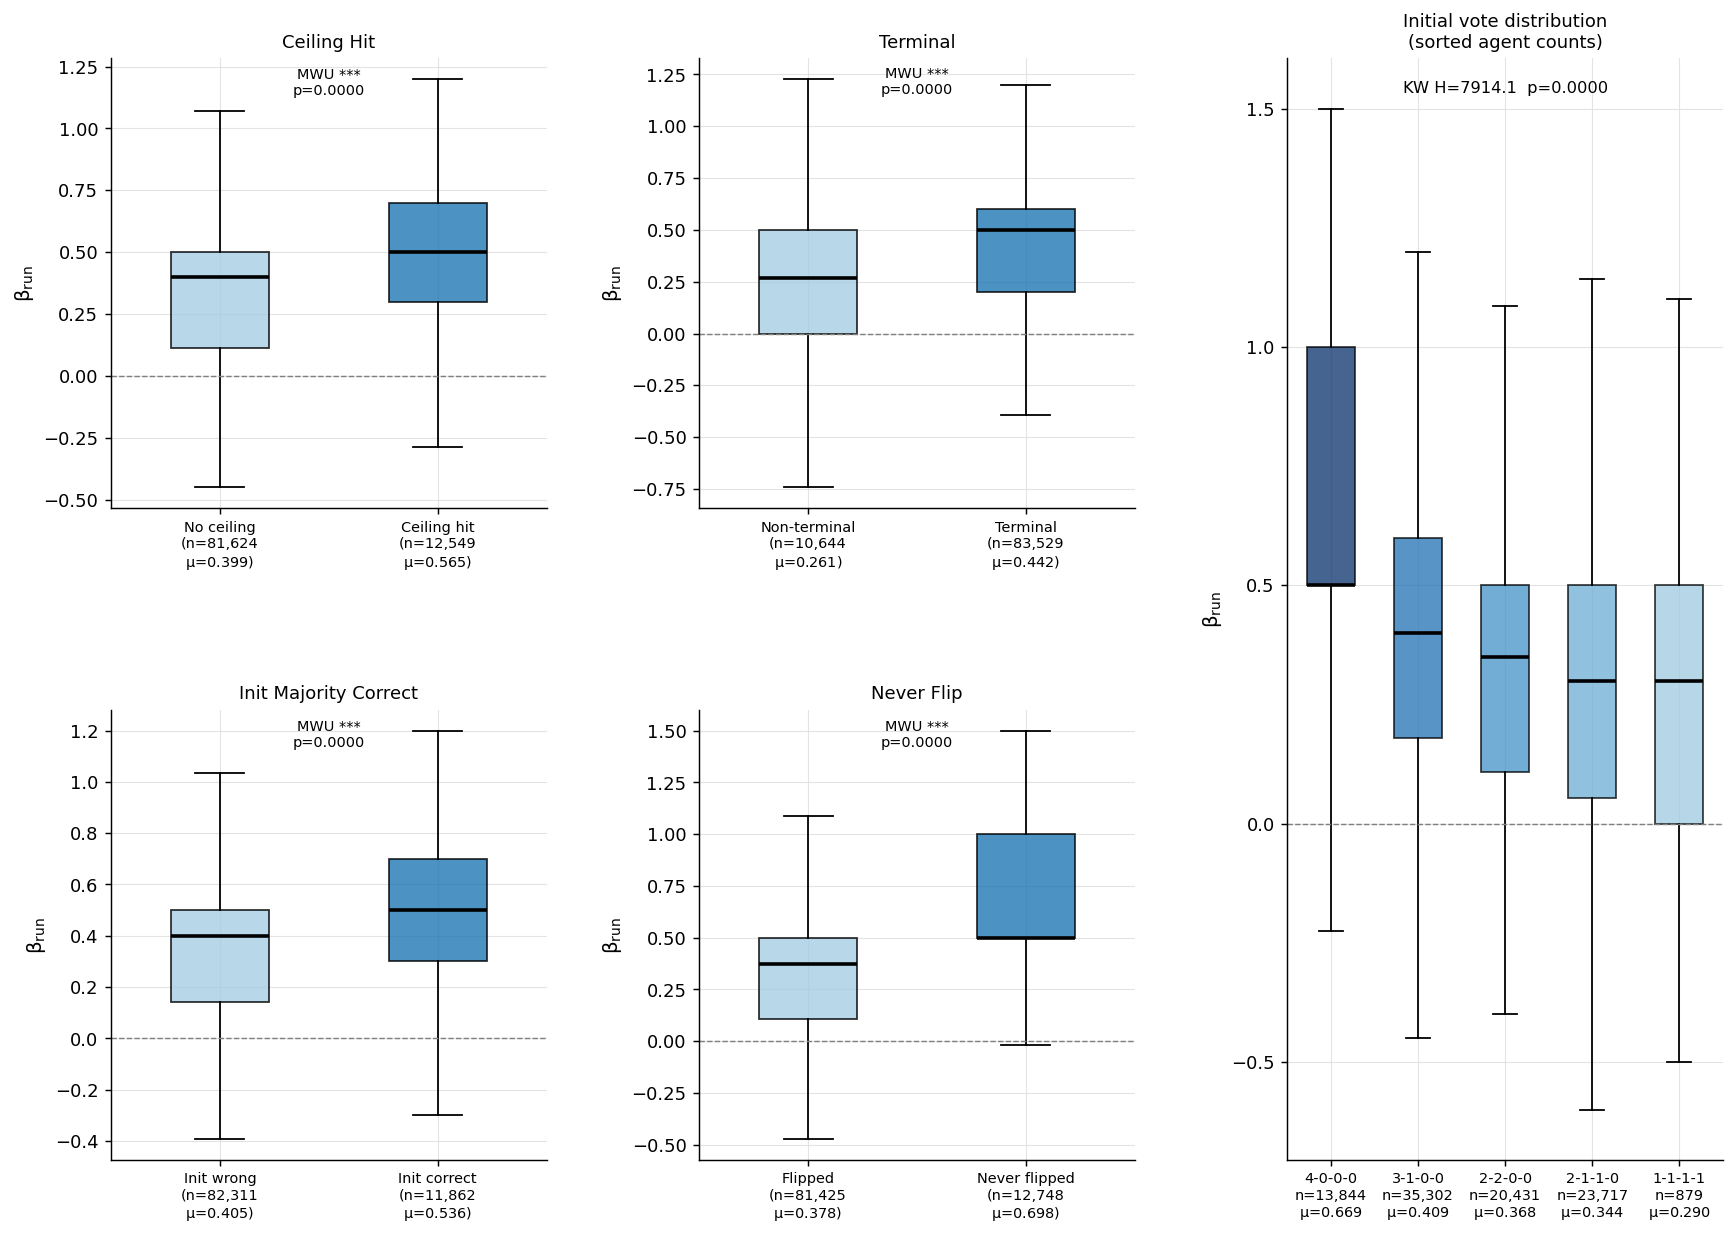

fig6 saved


In [11]:
DIST_ORDER  = ['4-0-0-0', '3-1-0-0', '2-2-0-0', '2-1-1-0', '1-1-1-1']
DIST_COLORS = ['#08306B', '#2171B5', '#4292C6', '#6BAED6', '#9ECAE1']
BINARY_PAIRS = [
    ('ceiling_hit',           False,  True,   'No ceiling',    'Ceiling hit'),
    ('terminal',              False,  True,   'Non-terminal',  'Terminal'),
    ('init_majority_correct', False,  True,   'Init wrong',    'Init correct'),
    ('never_flip',            False,  True,   'Flipped',       'Never flipped'),
]

# Fig 6 — subgroups
fig = plt.figure(figsize=(16, 11))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

positions = [(0,0),(0,1),(1,0),(1,1)]
for ax_pos, (col, val_lo, val_hi, lbl_lo, lbl_hi) in zip(positions, BINARY_PAIRS):
    ax  = fig.add_subplot(gs[ax_pos])
    lo  = runs_df[runs_df[col] == val_lo]['slope'].dropna().values
    hi  = runs_df[runs_df[col] == val_hi]['slope'].dropna().values
    bp  = ax.boxplot([lo, hi], patch_artist=True, notch=False,
                     showfliers=False, widths=0.45,
                     medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set(facecolor='#a6cee3', alpha=0.8)
    bp['boxes'][1].set(facecolor='#1f78b4', alpha=0.8)
    stat, p = sp_stats.mannwhitneyu(hi, lo, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        [f'{lbl_lo}\n(n={len(lo):,}\n$\mu$={lo.mean():.3f})',
         f'{lbl_hi}\n(n={len(hi):,}\n$\mu$={hi.mean():.3f})'],
        fontsize=8
    )
    ax.set_ylabel(r'$\beta_{run}$')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    y_top = ax.get_ylim()[1]
    ax.annotate(f'MWU {sig}\np={p:.4f}',
                xy=(1.5, y_top * 0.97), ha='center', va='top', fontsize=8)

ax5 = fig.add_subplot(gs[:, 2])
data_dist  = [runs_df[runs_df['init_dist'] == d]['slope'].dropna().values for d in DIST_ORDER]
ns_dist    = [len(x) for x in data_dist]
means_dist = [x.mean() if len(x) else np.nan for x in data_dist]
bp2 = ax5.boxplot(data_dist, patch_artist=True, notch=False,
                  showfliers=False, widths=0.55,
                  medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], DIST_COLORS):
    patch.set(facecolor=color, alpha=0.75)
ax5.set_xticks(range(1, len(DIST_ORDER)+1))
ax5.set_xticklabels(
    [f'{d}\nn={ns_dist[i]:,}\n$\mu$={means_dist[i]:.3f}'
     for i, d in enumerate(DIST_ORDER)], fontsize=8)
ax5.set_ylabel(r'$\beta_{run}$')
ax5.set_title('Initial vote distribution\n(sorted agent counts)', fontsize=10)
ax5.axhline(0, color='grey', linewidth=0.8, linestyle='--')
valid = [d for d in data_dist if len(d) > 1]
stat_kw, p_kw = sp_stats.kruskal(*valid)
ax5.text(0.5, 0.98, f'KW H={stat_kw:.1f}  p={p_kw:.4f}',
         transform=ax5.transAxes, ha='center', va='top', fontsize=9)

plt.tight_layout()
fig.savefig(EXPORT / 'fig6_subgroups.png')
plt.show()
print('fig6 saved')

---
## Part 4 — Efficiency and Accuracy

In [12]:
# Efficiency: Spearman n_rounds ~ mean_slope
print('=== Rep-level Spearman: n_rounds ~ mean_slope ===')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            sub = (reps_df[(reps_df['dataset']==ds) &
                           (reps_df['topology']==topo) &
                           (reps_df['W']==w)].dropna(subset=['mean_slope']))
            r, p = sp_stats.spearmanr(sub['mean_slope'], sub['n_rounds'])
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  '
                  f'rho={r:.3f}  p={p:.4f}  mean_rounds={sub["n_rounds"].mean():.2f}')

print()
print('=== Rep-level rpb: correct ~ mean_slope (GPQA only) ===')
for topo in TOPOS:
    for w in W_VALUES:
        sub = (reps_df[(reps_df['dataset']=='gpqa') &
                       (reps_df['topology']==topo) &
                       (reps_df['W']==w)].dropna(subset=['mean_slope']))
        r, p = sp_stats.pointbiserialr(sub['correct'].astype(int), sub['mean_slope'])
        acc  = sub.groupby('correct')['mean_slope'].mean()
        print(f'  GPQA {topo:5s} W={w}  rpb={r:.3f}  p={p:.4f}  '
              f'correct={acc.get(True,float("nan")):.3f}  incorrect={acc.get(False,float("nan")):.3f}')

print()
print('=== Rep-level rpb: correct ~ mean_slope (HiddenBench only) ===')
for topo in TOPOS:
    for w in W_VALUES:
        sub = (reps_df[(reps_df['dataset']=='hiddenbench') &
                       (reps_df['topology']==topo) &
                       (reps_df['W']==w)].dropna(subset=['mean_slope']))
        r, p = sp_stats.pointbiserialr(sub['correct'].astype(int), sub['mean_slope'])
        print(f'  HiddenBench {topo:5s} W={w}  rpb={r:.3f}  p={p:.4f}')

print()
print('=== Median split accuracy ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub    = reps_df[(reps_df['dataset']==ds) & (reps_df['topology']==topo)].dropna(subset=['mean_slope'])
        median = sub['mean_slope'].median()
        hi     = sub[sub['mean_slope'] >  median]['correct'].mean()
        lo     = sub[sub['mean_slope'] <= median]['correct'].mean()
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  high-SR={hi:.3f}  low-SR={lo:.3f}  diff={hi-lo:+.3f}')

=== Rep-level Spearman: n_rounds ~ mean_slope ===
  GPQA         fc    W=1  rho=-0.668  p=0.0000  mean_rounds=3.85
  GPQA         fc    W=2  rho=-0.745  p=0.0000  mean_rounds=3.64
  GPQA         fc    W=5  rho=-0.805  p=0.0000  mean_rounds=3.81
  GPQA         star  W=1  rho=-0.678  p=0.0000  mean_rounds=4.22
  GPQA         star  W=2  rho=-0.715  p=0.0000  mean_rounds=4.15
  GPQA         star  W=5  rho=-0.792  p=0.0000  mean_rounds=4.31
  HiddenBench  fc    W=1  rho=-0.646  p=0.0000  mean_rounds=5.47
  HiddenBench  fc    W=2  rho=-0.649  p=0.0000  mean_rounds=4.91
  HiddenBench  fc    W=5  rho=-0.708  p=0.0000  mean_rounds=4.99
  HiddenBench  star  W=1  rho=-0.751  p=0.0000  mean_rounds=7.56
  HiddenBench  star  W=2  rho=-0.737  p=0.0000  mean_rounds=6.78
  HiddenBench  star  W=5  rho=-0.725  p=0.0000  mean_rounds=6.54

=== Rep-level rpb: correct ~ mean_slope (GPQA only) ===
  GPQA fc    W=1  rpb=0.023  p=0.3428  correct=0.538  incorrect=0.526
  GPQA fc    W=2  rpb=-0.005  p=0.8309  cor

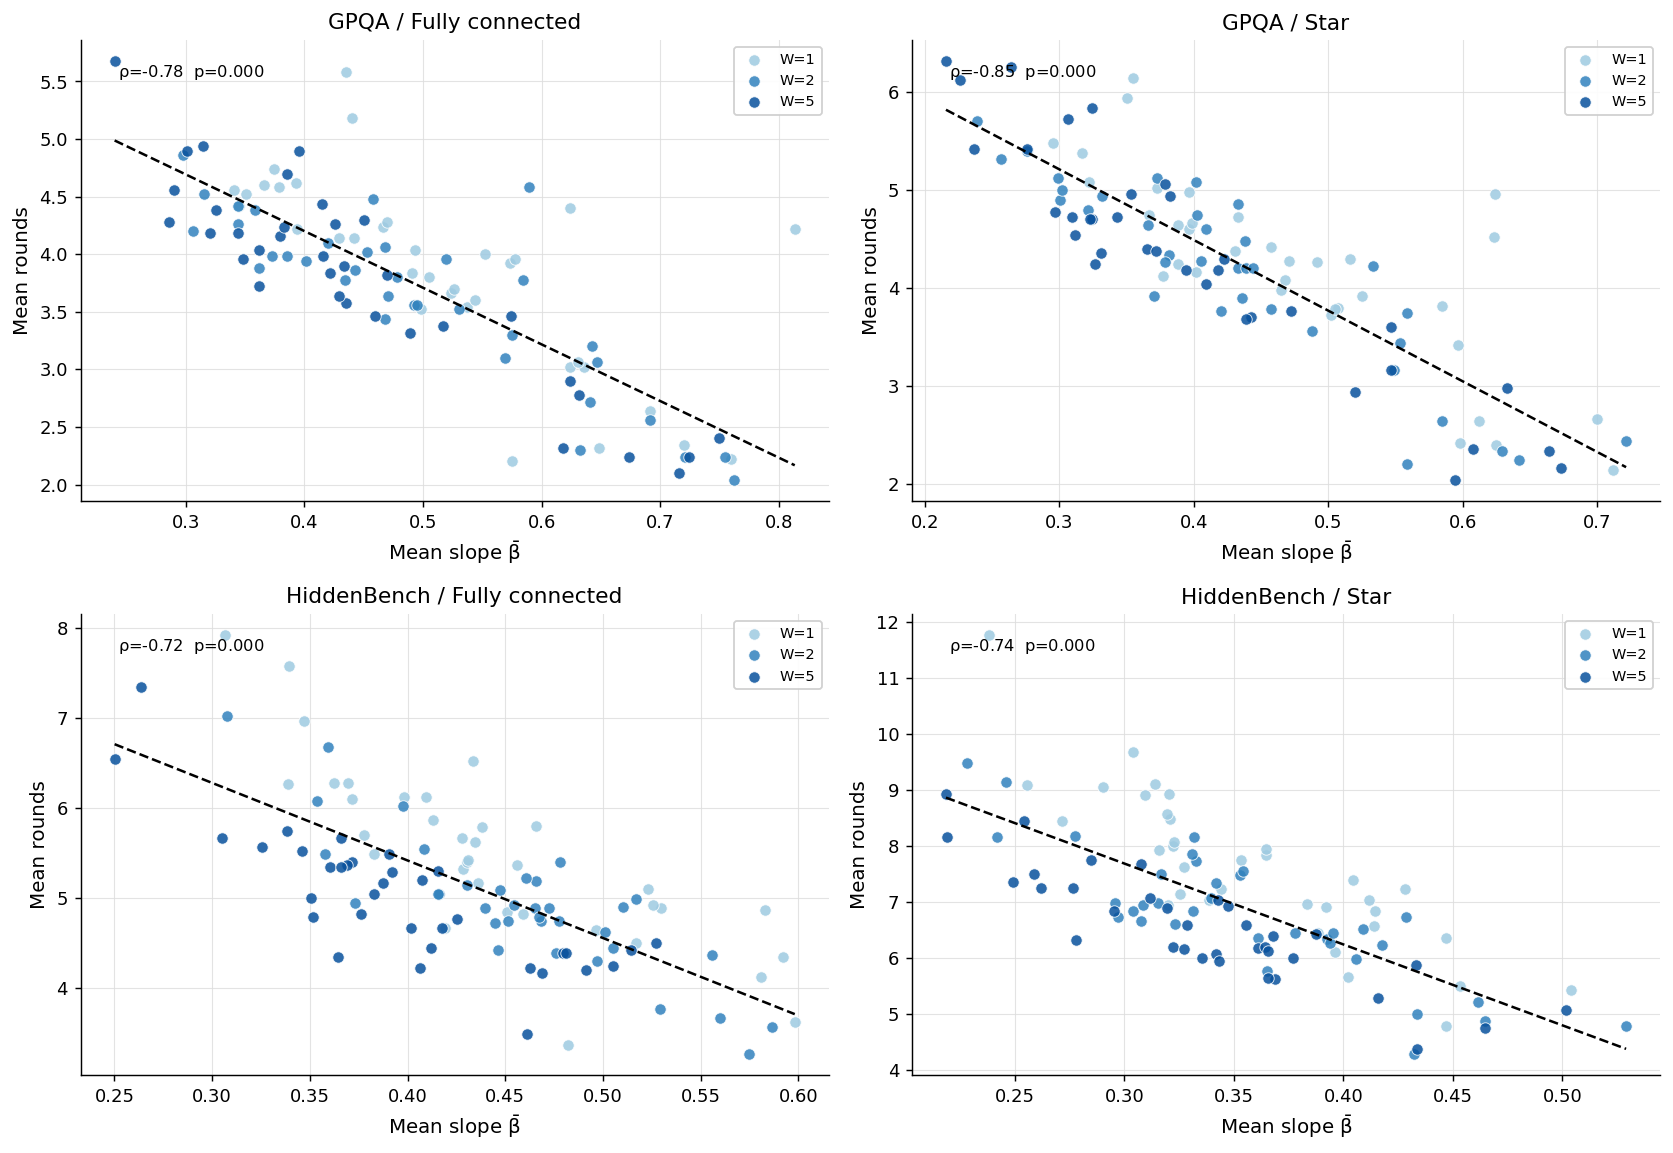

fig4 saved


In [13]:
# Fig 4 — efficiency scatter
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        for w in W_VALUES:
            sw = sub[sub['W']==w].dropna(subset=['mean_slope','mean_rounds'])
            ax.scatter(sw['mean_slope'], sw['mean_rounds'],
                       s=40, color=W_COLORS[w], alpha=0.85,
                       label=f'W={w}', edgecolors='white', linewidths=0.5)
        all_s = sub.dropna(subset=['mean_slope','mean_rounds'])
        m, b  = np.polyfit(all_s['mean_slope'], all_s['mean_rounds'], 1)
        xs    = np.linspace(all_s['mean_slope'].min(), all_s['mean_slope'].max(), 50)
        ax.plot(xs, m*xs + b, color='black', linewidth=1.4, linestyle='--')
        r, p  = sp_stats.spearmanr(all_s['mean_slope'], all_s['mean_rounds'])
        ax.text(0.05, 0.95, f'$\\rho$={r:.2f}  p={p:.3f}',
                transform=ax.transAxes, fontsize=9, va='top')
        ax.set_xlabel(r'Mean slope $\bar{\beta}$')
        ax.set_ylabel('Mean rounds')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(EXPORT / 'fig4_sr_efficiency.png')
plt.show()
print('fig4 saved')

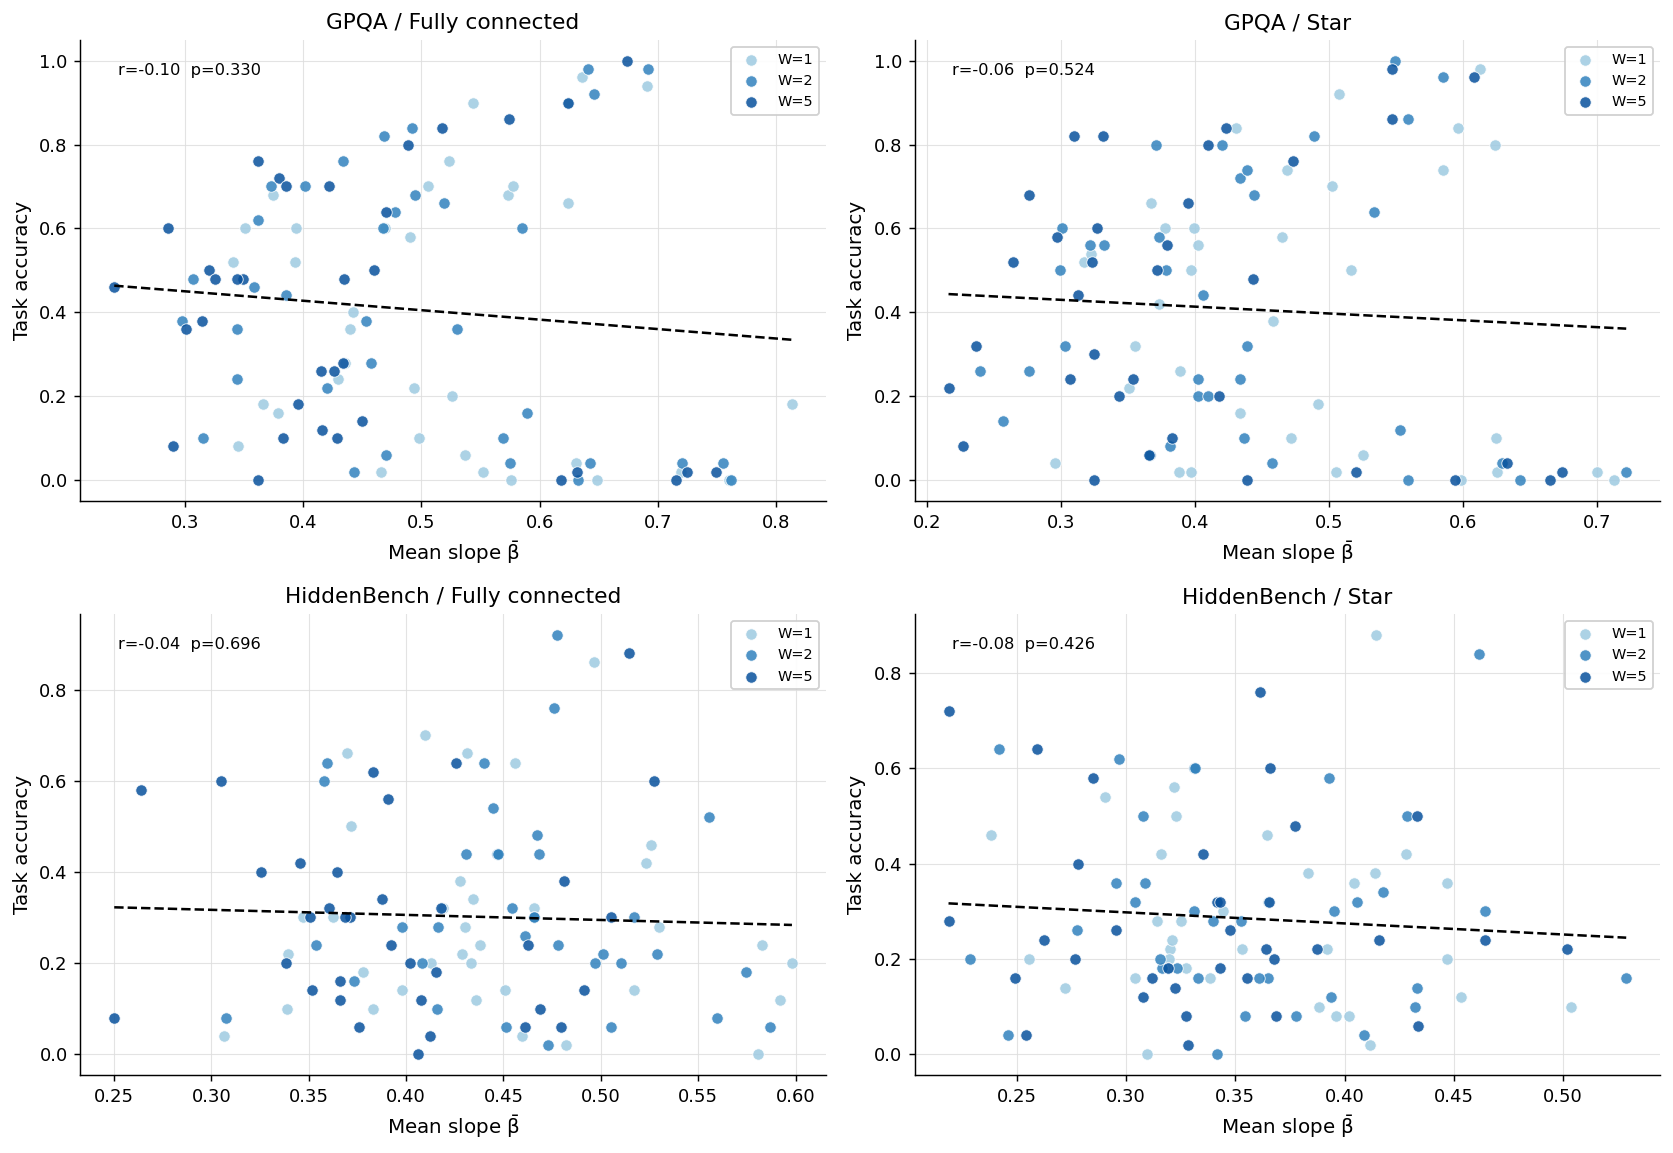

fig5 saved


In [14]:
# Fig 5 — accuracy scatter
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        for w in W_VALUES:
            sw = sub[sub['W']==w].dropna(subset=['mean_slope','accuracy'])
            ax.scatter(sw['mean_slope'], sw['accuracy'],
                       s=40, color=W_COLORS[w], alpha=0.85,
                       label=f'W={w}', edgecolors='white', linewidths=0.5)
        all_s = sub.dropna(subset=['mean_slope','accuracy'])
        m, b  = np.polyfit(all_s['mean_slope'], all_s['accuracy'], 1)
        xs    = np.linspace(all_s['mean_slope'].min(), all_s['mean_slope'].max(), 50)
        ax.plot(xs, m*xs + b, color='black', linewidth=1.4, linestyle='--')
        r, p  = sp_stats.pearsonr(all_s['mean_slope'], all_s['accuracy'])
        ax.text(0.05, 0.95, f'r={r:.2f}  p={p:.3f}',
                transform=ax.transAxes, fontsize=9, va='top')
        ax.set_xlabel(r'Mean slope $\bar{\beta}$')
        ax.set_ylabel('Task accuracy')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(EXPORT / 'fig5_sr_accuracy.png')
plt.show()
print('fig5 saved')

---
## Part 5 — Mediation: Initial Diversity → SR → Rounds

In [15]:
from collections import Counter as _C

# Build rep-level diversity (Herfindahl)
def hhi_diversity(votes):
    n = len(votes)
    cnts = _C(votes)
    return 1 - sum((v/n)**2 for v in cnts.values())

div_rows = []
for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W, ds, topo, qid = d['W'], d['dataset'], d.get('topology_name','fc'), d['question_id']
    for rep_idx, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']
        N    = rep['N']
        init_votes = [traj[0]['phase_b'][i]['vote'] for i in range(N)]
        div_rows.append({
            'W': W, 'dataset': ds, 'topology': topo, 'qid': qid,
            'rep_idx': rep_idx, 'diversity': hhi_diversity(init_votes),
        })

div_df = pd.DataFrame(div_rows)
med_df = reps_df.merge(div_df, on=['W','dataset','topology','qid','rep_idx'])
med_df = med_df.dropna(subset=['mean_slope'])
print(f'Mediation sample: {len(med_df):,} reps')

# Z-score within config
for col in ['diversity','mean_slope','n_rounds']:
    med_df[f'z_{col}'] = med_df.groupby(['dataset','topology','W'])[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

from scipy.stats import linregress

def ols(x, y):
    r = linregress(x.values, y.values)
    return r.slope, r.pvalue

# Step 1: X -> Y
b_total, p1 = ols(med_df['z_diversity'], med_df['z_n_rounds'])
# Step 2: X -> M
b_xm, p2 = ols(med_df['z_diversity'], med_df['z_mean_slope'])
# Step 3: M -> Y | X  (multiple regression)
from numpy.linalg import lstsq
X3 = np.column_stack([med_df['z_diversity'], med_df['z_mean_slope'], np.ones(len(med_df))])
b3, _, _, _ = lstsq(X3, med_df['z_n_rounds'].values, rcond=None)
b_direct = b3[0]
b_med    = b3[1]

# Bootstrap indirect
N_BOOT = 5000
rng = np.random.default_rng(0)
inds = []
for _ in range(N_BOOT):
    idx = rng.integers(0, len(med_df), len(med_df))
    sub = med_df.iloc[idx]
    a,_ = ols(sub['z_diversity'], sub['z_mean_slope'])
    X_ = np.column_stack([sub['z_diversity'], sub['z_mean_slope'], np.ones(len(sub))])
    b_, _, _, _ = lstsq(X_, sub['z_n_rounds'].values, rcond=None)
    inds.append(a * b_[1])

indirect = b_xm * b_med
ci_lo, ci_hi = np.percentile(inds, [2.5, 97.5])
prop_med = indirect / b_total

print(f'\nBaron-Kenny Mediation: diversity(X) -> SR(M) -> rounds(Y)')
print(f'  Step1 X->Y (total):       b={b_total:+.3f}  p={p1:.4f}')
print(f'  Step2 X->M:               b={b_xm:+.3f}  p={p2:.4f}')
print(f'  Step3 M->Y|X:             b={b_med:+.3f}')
print(f'  Step3 X->Y|M (direct):    b={b_direct:+.3f}')
print(f'  Indirect a*b:             {indirect:+.3f}')
print(f'  Bootstrap 95% CI:         [{ci_lo:.3f}, {ci_hi:.3f}]')
print(f'  Proportion mediated:      {prop_med:.0%}')

print()
print('=== By dataset ===')
for ds in DATASETS:
    sub = med_df[med_df['dataset']==ds]
    b_t, _ = ols(sub['z_diversity'], sub['z_n_rounds'])
    a_, _  = ols(sub['z_diversity'], sub['z_mean_slope'])
    X_ = np.column_stack([sub['z_diversity'], sub['z_mean_slope'], np.ones(len(sub))])
    b_, _, _, _ = lstsq(X_, sub['z_n_rounds'].values, rcond=None)
    ind_ = a_ * b_[1]
    print(f'  {DS_LABELS[ds]:12s}  indirect={ind_:.3f}  direct={b_[0]:.3f}  prop={ind_/b_t:.0%}')

Mediation sample: 20,997 reps



Baron-Kenny Mediation: diversity(X) -> SR(M) -> rounds(Y)
  Step1 X->Y (total):       b=+0.402  p=0.0000
  Step2 X->M:               b=-0.376  p=0.0000
  Step3 M->Y|X:             b=-0.542
  Step3 X->Y|M (direct):    b=+0.199
  Indirect a*b:             +0.204
  Bootstrap 95% CI:         [0.194, 0.214]
  Proportion mediated:      51%

=== By dataset ===
  GPQA          indirect=0.237  direct=0.302  prop=44%
  HiddenBench   indirect=0.127  direct=0.139  prop=48%


---
## Part 6 — Verified corrections (provenance, task-level, BH-FDR)

In [16]:
from src.metrics.stats_utils import (
    task_paired_wilcoxon, task_spearman, bh_fdr,
)
import statsmodels.api as sm

aug_rows = []
for f in sorted(BASE.glob('**/*.json')):
    d = json.loads(f.read_text())
    W, ds, topo, qid, gt = (d['W'], d['dataset'], d.get('topology_name','fc'),
                            d['question_id'], d['ground_truth'])
    for rep_idx, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']; T_r = len(traj) - 1; N = len(traj[0]['phase_b'])
        init_votes = [traj[0]['phase_b'][i]['vote'] for i in range(N)]
        conf0 = np.array([float(traj[0]['phase_b'][i].get('confidence') or 0.0) for i in range(N)])
        confT = np.array([float(traj[T_r]['phase_b'][i].get('confidence') or 0.0) for i in range(N)])
        aug_rows.append({'W': W, 'dataset': ds, 'topology': topo, 'qid': qid, 'rep_idx': rep_idx,
                         'gt_present': gt in init_votes,
                         'conf_gain': float((confT - conf0).mean())})

acc_df = (reps_df.merge(pd.DataFrame(aug_rows),
                        on=['W','dataset','topology','qid','rep_idx'])
          .dropna(subset=['mean_slope']))
acc_df['correct_int'] = acc_df['correct'].astype(int)
acc_df['gt_int']      = acc_df['gt_present'].astype(int)
FAM = {}
print(f'acc_df rows: {len(acc_df):,}')

acc_df rows: 20,997


In [17]:
print('=== PART 4b — ACCURACY AMPLIFICATION (rep-level provenance) ===')
print()
print('(a) marginal rpb per cell:')
marg_ps, marg_ms = [], []
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            s = acc_df[(acc_df.dataset==ds)&(acc_df.topology==topo)&(acc_df.W==w)]
            r_ps, _ = sp_stats.pointbiserialr(s['correct_int'], s['p_sr'].fillna(0))
            r_ms, _ = sp_stats.pointbiserialr(s['correct_int'], s['mean_slope'])
            marg_ps.append(r_ps); marg_ms.append(r_ms)
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  rpb(p_sr)={r_ps:+.3f}  rpb(mean_slope)={r_ms:+.3f}')
print(f'  marginal rpb max (mean_slope) = {max(marg_ms):+.4f}   (p_sr) = {max(marg_ps):+.4f}')
print()

print('(b) GT-presence split + rpb(mean_slope, correct) within subset:')
simpson_ps = []
for ds in DATASETS:
    s = acc_df[acc_df.dataset==ds]
    print(f'  {DS_LABELS[ds]}: GT-absent frac={1-s.gt_int.mean():.3f}  GT-present frac={s.gt_int.mean():.3f}')
    for lab, sub in [('absent', s[~s.gt_present]), ('present', s[s.gt_present])]:
        r, p = sp_stats.pointbiserialr(sub['correct_int'], sub['mean_slope'])
        simpson_ps.append((f'{DS_LABELS[ds]} GT-{lab}', p))
        print(f'     GT-{lab:8s} rpb={r:+.3f}  p={p:.2e}  n={len(sub):,}')
FAM['simpson_gt_split'] = simpson_ps
print()

print('(c) SR x GT_presence interaction (linear probability model):')
for ds in DATASETS:
    s = acc_df[acc_df.dataset==ds].copy()
    s['z'] = (s['mean_slope'] - s['mean_slope'].mean()) / s['mean_slope'].std()
    for xcol, lab in [('z','z-scored'), ('mean_slope','raw-unit')]:
        X = sm.add_constant(pd.DataFrame({'x': s[xcol], 'gt': s['gt_int'], 'xgt': s[xcol]*s['gt_int']}))
        m = sm.OLS(s['correct_int'], X).fit()
        print(f'  {DS_LABELS[ds]:12s} {lab:9s} interaction coef={m.params["xgt"]:+.4f}  p={m.pvalues["xgt"]:.2e}')
print()

print('(d) amplification: rpb(init_correct_frac, correct) high-SR vs low-SR (median split):')
for ds in DATASETS:
    s = acc_df[acc_df.dataset==ds]; med = s['mean_slope'].median()
    hi = s[s.mean_slope >  med]; lo = s[s.mean_slope <= med]
    rh, _ = sp_stats.pointbiserialr(hi['correct_int'], hi['init_correct_frac'])
    rl, _ = sp_stats.pointbiserialr(lo['correct_int'], lo['init_correct_frac'])
    print(f'  {DS_LABELS[ds]:12s} high-SR r={rh:.3f}  low-SR r={rl:.3f}')
print()

print('(e) confidence gain mean, correct vs incorrect:')
for ds in DATASETS:
    s = acc_df[acc_df.dataset==ds]
    print(f'  {DS_LABELS[ds]:12s} correct={s[s.correct]["conf_gain"].mean():.3f}  '
          f'incorrect={s[~s.correct]["conf_gain"].mean():.3f}')

=== PART 4b — ACCURACY AMPLIFICATION (rep-level provenance) ===

(a) marginal rpb per cell:
  GPQA         fc    W=1  rpb(p_sr)=-0.014  rpb(mean_slope)=+0.023
  GPQA         fc    W=2  rpb(p_sr)=+0.029  rpb(mean_slope)=-0.005
  GPQA         fc    W=5  rpb(p_sr)=-0.039  rpb(mean_slope)=+0.003
  GPQA         star  W=1  rpb(p_sr)=+0.008  rpb(mean_slope)=+0.015
  GPQA         star  W=2  rpb(p_sr)=+0.010  rpb(mean_slope)=-0.007
  GPQA         star  W=5  rpb(p_sr)=+0.003  rpb(mean_slope)=+0.002
  HiddenBench  fc    W=1  rpb(p_sr)=+0.017  rpb(mean_slope)=+0.049
  HiddenBench  fc    W=2  rpb(p_sr)=-0.033  rpb(mean_slope)=+0.026
  HiddenBench  fc    W=5  rpb(p_sr)=+0.005  rpb(mean_slope)=+0.030
  HiddenBench  star  W=1  rpb(p_sr)=+0.011  rpb(mean_slope)=+0.036
  HiddenBench  star  W=2  rpb(p_sr)=+0.032  rpb(mean_slope)=+0.052
  HiddenBench  star  W=5  rpb(p_sr)=-0.013  rpb(mean_slope)=+0.034
  marginal rpb max (mean_slope) = +0.0516   (p_sr) = +0.0315

(b) GT-presence split + rpb(mean_slope, co

In [18]:
print('=== TASK-LEVEL (n~35) CORRECTIONS ===')
print()
print('(1) Init-vote-distribution effect: task-paired Wilcoxon 4-0-0-0 vs 1-1-1-1 mean-slope (GPQA):')
g = runs_df[runs_df.dataset=='gpqa']
a = g[g.init_dist=='4-0-0-0'].groupby('qid')['slope'].mean()
b = g[g.init_dist=='1-1-1-1'].groupby('qid')['slope'].mean()
common = a.index.intersection(b.index)
stat, p, mdiff, n = task_paired_wilcoxon(a[common].values, b[common].values)
print(f'  n={n}  median_diff(4-0-0-0 - 1-1-1-1)={mdiff:+.3f}  W={stat:.1f}  p={p:.3e}')
print()

print('(2) Efficiency task-level Spearman mean_slope ~ mean_rounds per cell:')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            s = tasks_df[(tasks_df.dataset==ds)&(tasks_df.topology==topo)&(tasks_df.W==w)]
            rho, p, n = task_spearman(s['mean_slope'], s['mean_rounds'])
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  rho={rho:+.3f}  p={p:.2e}  n={n}')
print()

def _rpb_cluster_ci(sub, n_boot=2000, seed=0):
    qids = sub['qid'].unique()
    groups = {q: sub[sub.qid==q] for q in qids}
    obs = sp_stats.pointbiserialr(sub['correct_int'], sub['mean_slope'])[0]
    rng = np.random.default_rng(seed); boot = np.empty(n_boot)
    for i in range(n_boot):
        cat = pd.concat([groups[q] for q in rng.choice(qids, len(qids), True)])
        boot[i] = sp_stats.pointbiserialr(cat['correct_int'], cat['mean_slope'])[0]
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(obs), float(lo), float(hi)

print('(3) GT-absent SR-accuracy rpb with task-cluster bootstrap 95% CI:')
for ds in DATASETS:
    sub = acc_df[(acc_df.dataset==ds)&(~acc_df.gt_present)]
    o, lo, hi = _rpb_cluster_ci(sub)
    verdict = 'survives (excludes 0)' if (hi < 0 or lo > 0) else 'ns (includes 0)'
    print(f'  {DS_LABELS[ds]:12s} rpb={o:+.3f}  CI[{lo:.3f}, {hi:.3f}]  {verdict}')
print()

print('(4) Confidence-gain task-paired Wilcoxon (correct vs incorrect):')
confgain_ps = []
for ds in DATASETS:
    s = acc_df[acc_df.dataset==ds]
    c = s[s.correct].groupby('qid')['conf_gain'].mean()
    ic = s[~s.correct].groupby('qid')['conf_gain'].mean()
    common = c.index.intersection(ic.index)
    stat, p, mdiff, n = task_paired_wilcoxon(c[common].values, ic[common].values)
    confgain_ps.append((DS_LABELS[ds], p))
    print(f'  {DS_LABELS[ds]:12s} n={n}  median_diff(correct - incorrect)={mdiff:+.3f}  p={p:.4f}')
FAM['confidence_gain'] = confgain_ps

=== TASK-LEVEL (n~35) CORRECTIONS ===

(1) Init-vote-distribution effect: task-paired Wilcoxon 4-0-0-0 vs 1-1-1-1 mean-slope (GPQA):
  n=21  median_diff(4-0-0-0 - 1-1-1-1)=+0.424  W=0.0  p=9.537e-07

(2) Efficiency task-level Spearman mean_slope ~ mean_rounds per cell:
  GPQA         fc    W=1  rho=-0.777  p=4.04e-08  n=35
  GPQA         fc    W=2  rho=-0.819  p=1.75e-09  n=35
  GPQA         fc    W=5  rho=-0.852  p=8.33e-11  n=35
  GPQA         star  W=1  rho=-0.778  p=3.69e-08  n=35
  GPQA         star  W=2  rho=-0.898  p=2.76e-13  n=35
  GPQA         star  W=5  rho=-0.912  p=2.47e-14  n=35
  HiddenBench  fc    W=1  rho=-0.831  p=6.16e-10  n=35
  HiddenBench  fc    W=2  rho=-0.765  p=8.71e-08  n=35
  HiddenBench  fc    W=5  rho=-0.788  p=1.97e-08  n=35
  HiddenBench  star  W=1  rho=-0.868  p=1.38e-11  n=35
  HiddenBench  star  W=2  rho=-0.798  p=9.18e-09  n=35
  HiddenBench  star  W=5  rho=-0.854  p=6.99e-11  n=35

(3) GT-absent SR-accuracy rpb with task-cluster bootstrap 95% CI:


  GPQA         rpb=-0.112  CI[-0.163, -0.059]  survives (excludes 0)


  HiddenBench  rpb=-0.041  CI[-0.084, 0.010]  ns (includes 0)

(4) Confidence-gain task-paired Wilcoxon (correct vs incorrect):
  GPQA         n=34  median_diff(correct - incorrect)=-0.050  p=0.1012
  HiddenBench  n=35  median_diff(correct - incorrect)=+0.054  p=0.0040


In [19]:
print('(5) Mediation indirect-effect: task-stratified (cluster) bootstrap CI:')
from scipy.stats import linregress as _lr
from numpy.linalg import lstsq as _lstsq

def _indirect_prop(sub):
    a = _lr(sub['z_diversity'].values, sub['z_mean_slope'].values).slope
    X = np.column_stack([sub['z_diversity'], sub['z_mean_slope'], np.ones(len(sub))])
    bcoef, _, _, _ = _lstsq(X, sub['z_n_rounds'].values, rcond=None)
    b_total = _lr(sub['z_diversity'].values, sub['z_n_rounds'].values).slope
    ind = a * bcoef[1]
    return ind, ind / b_total

ind, prop = _indirect_prop(med_df)
qids = med_df['qid'].unique()
groups = {q: med_df[med_df.qid==q] for q in qids}
rng = np.random.default_rng(0); boot = np.empty(2000)
for i in range(2000):
    cat = pd.concat([groups[q] for q in rng.choice(qids, len(qids), True)])
    boot[i] = _indirect_prop(cat)[0]
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f'  indirect a*b={ind:.3f}  prop mediated={prop:.0%}  task-cluster CI[{lo:.3f}, {hi:.3f}]')
print('  (rep-level CI [0.194, 0.214] was too tight; task-cluster CI is the honest one)')

(5) Mediation indirect-effect: task-stratified (cluster) bootstrap CI:


  indirect a*b=0.204  prop mediated=51%  task-cluster CI[0.160, 0.246]
  (rep-level CI [0.194, 0.214] was too tight; task-cluster CI is the honest one)


In [20]:
print('=== VALUE FIXES ===')
print()
print('Dataset comparison GPQA vs HiddenBench (MWU two-sided) — all six:')
ds_labs, ds_ps = [], []
for topo in TOPOS:
    for w in W_VALUES:
        g = tasks_df[(tasks_df.dataset=='gpqa')&(tasks_df.topology==topo)&(tasks_df.W==w)]['mean_slope'].dropna()
        h = tasks_df[(tasks_df.dataset=='hiddenbench')&(tasks_df.topology==topo)&(tasks_df.W==w)]['mean_slope'].dropna()
        _, p = sp_stats.mannwhitneyu(g, h, alternative='two-sided')
        star = '***' if p < 0.001 else ('**' if p < 0.005 else ('*' if p < 0.05 else 'ns'))
        ds_labs.append(f'{topo} W={w}'); ds_ps.append(p)
        print(f'  {topo:5s} W={w}  GPQA={g.mean():.3f}  HB={h.mean():.3f}  p={p:.4f}  {star}')
FAM['dataset_gpqa_hb'] = list(zip(ds_labs, ds_ps))

=== VALUE FIXES ===

Dataset comparison GPQA vs HiddenBench (MWU two-sided) — all six:
  fc    W=1  GPQA=0.519  HB=0.444  p=0.0077  *
  fc    W=2  GPQA=0.498  HB=0.459  p=0.3181  ns
  fc    W=5  GPQA=0.449  HB=0.398  p=0.2497  ns
  star  W=1  GPQA=0.474  HB=0.358  p=0.0000  ***
  star  W=2  GPQA=0.432  HB=0.356  p=0.0027  **
  star  W=5  GPQA=0.401  HB=0.337  p=0.0471  *


In [21]:
print('=== BH-FDR (q-values within each family, alpha=0.05) ===')

sr_page_labs, sr_page_ps = [], []
for ds in DATASETS:
    for topo in TOPOS:
        sub = tasks_df[(tasks_df.dataset==ds)&(tasks_df.topology==topo)]
        mat = sub.pivot(index='qid', columns='W', values='mean_slope')[W_VALUES].dropna()
        up   = sp_stats.page_trend_test(mat.values).pvalue
        down = sp_stats.page_trend_test(mat.values[:, ::-1]).pvalue
        sr_page_labs.append(f'{DS_LABELS[ds]} {topo}'); sr_page_ps.append(min(up, down))
FAM['sr_page_trend'] = list(zip(sr_page_labs, sr_page_ps))

topo_labs, topo_ps = [], []
for ds in DATASETS:
    for w in W_VALUES:
        fc   = tasks_df[(tasks_df.dataset==ds)&(tasks_df.topology=='fc')&(tasks_df.W==w)]['mean_slope'].dropna()
        star = tasks_df[(tasks_df.dataset==ds)&(tasks_df.topology=='star')&(tasks_df.W==w)]['mean_slope'].dropna()
        _, p = sp_stats.mannwhitneyu(fc, star, alternative='two-sided')
        topo_labs.append(f'{DS_LABELS[ds]} W={w}'); topo_ps.append(p)
FAM['topo_fc_star'] = list(zip(topo_labs, topo_ps))

for fam_name, pairs in FAM.items():
    labs = [l for l, _ in pairs]; ps = [p for _, p in pairs]
    q, rej = bh_fdr(ps)
    print(f'--- {fam_name} ({len(ps)} tests) ---')
    for l, p, qq, r in zip(labs, ps, q, rej):
        print(f'  {l:26s} p={p:.4e}  q={qq:.4e}  {"survives" if r else "ns"}')
    print()

=== BH-FDR (q-values within each family, alpha=0.05) ===
--- simpson_gt_split (4 tests) ---
  GPQA GT-absent             p=1.1179e-10  q=1.4905e-10  survives
  GPQA GT-present            p=3.0173e-63  q=1.2069e-62  survives
  HiddenBench GT-absent      p=2.1935e-03  q=2.1935e-03  survives
  HiddenBench GT-present     p=5.5109e-36  q=1.1022e-35  survives

--- confidence_gain (2 tests) ---
  GPQA                       p=1.0123e-01  q=1.0123e-01  ns
  HiddenBench                p=4.0291e-03  q=8.0581e-03  survives

--- dataset_gpqa_hb (6 tests) ---
  fc W=1                     p=7.6677e-03  q=1.5335e-02  survives
  fc W=2                     p=3.1808e-01  q=3.1808e-01  ns
  fc W=5                     p=2.4968e-01  q=2.9962e-01  ns
  star W=1                   p=9.4989e-06  q=5.6993e-05  survives
  star W=2                   p=2.7422e-03  q=8.2265e-03  survives
  star W=5                   p=4.7135e-02  q=7.0702e-02  ns

--- sr_page_trend (4 tests) ---
  GPQA fc                    p=1.5704

In [22]:
# Summary overview table
overview = tasks_df.groupby(['dataset','topology','W']).agg(
    n_tasks=('qid','nunique'),
    p_sr=('p_sr','mean'),
    mean_slope=('mean_slope','mean'),
    accuracy=('accuracy','mean'),
    mean_rounds=('mean_rounds','mean'),
).round(3)
print('=== OVERVIEW TABLE ===')
print(overview.to_string())

=== OVERVIEW TABLE ===
                        n_tasks   p_sr  mean_slope  accuracy  mean_rounds
dataset     topology W                                                   
gpqa        fc       1       35  0.825       0.519     0.396        3.853
                     2       35  0.815       0.498     0.420        3.638
                     5       35  0.769       0.449     0.406        3.805
            star     1       35  0.813       0.474     0.399        4.223
                     2       35  0.775       0.432     0.411        4.158
                     5       35  0.742       0.401     0.412        4.315
hiddenbench fc       1       35  0.851       0.444     0.288        5.467
                     2       35  0.875       0.459     0.321        4.908
                     5       35  0.825       0.398     0.297        4.988
            star     1       35  0.835       0.358     0.278        7.559
                     2       35  0.817       0.356     0.294        6.782
               